# Decision Tree

In [48]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier,plot_tree,DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,r2_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
data = pd.read_csv("./dataset/loan.csv")
df = data
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [36]:
le = LabelEncoder()
df["previous_loan_defaults_on_file"] = le.fit_transform(df["previous_loan_defaults_on_file"])

In [37]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [82]:
columns = df.columns.tolist()
columns = columns[:-1]
x = df[["previous_loan_defaults_on_file","loan_percent_income","loan_int_rate","person_home_ownership"]]
y = df["loan_status"]

In [83]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = .2 ,random_state = 43)

In [84]:
model  = DecisionTreeClassifier(criterion = "gini")
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [85]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
accuracy*100

87.97777777777777

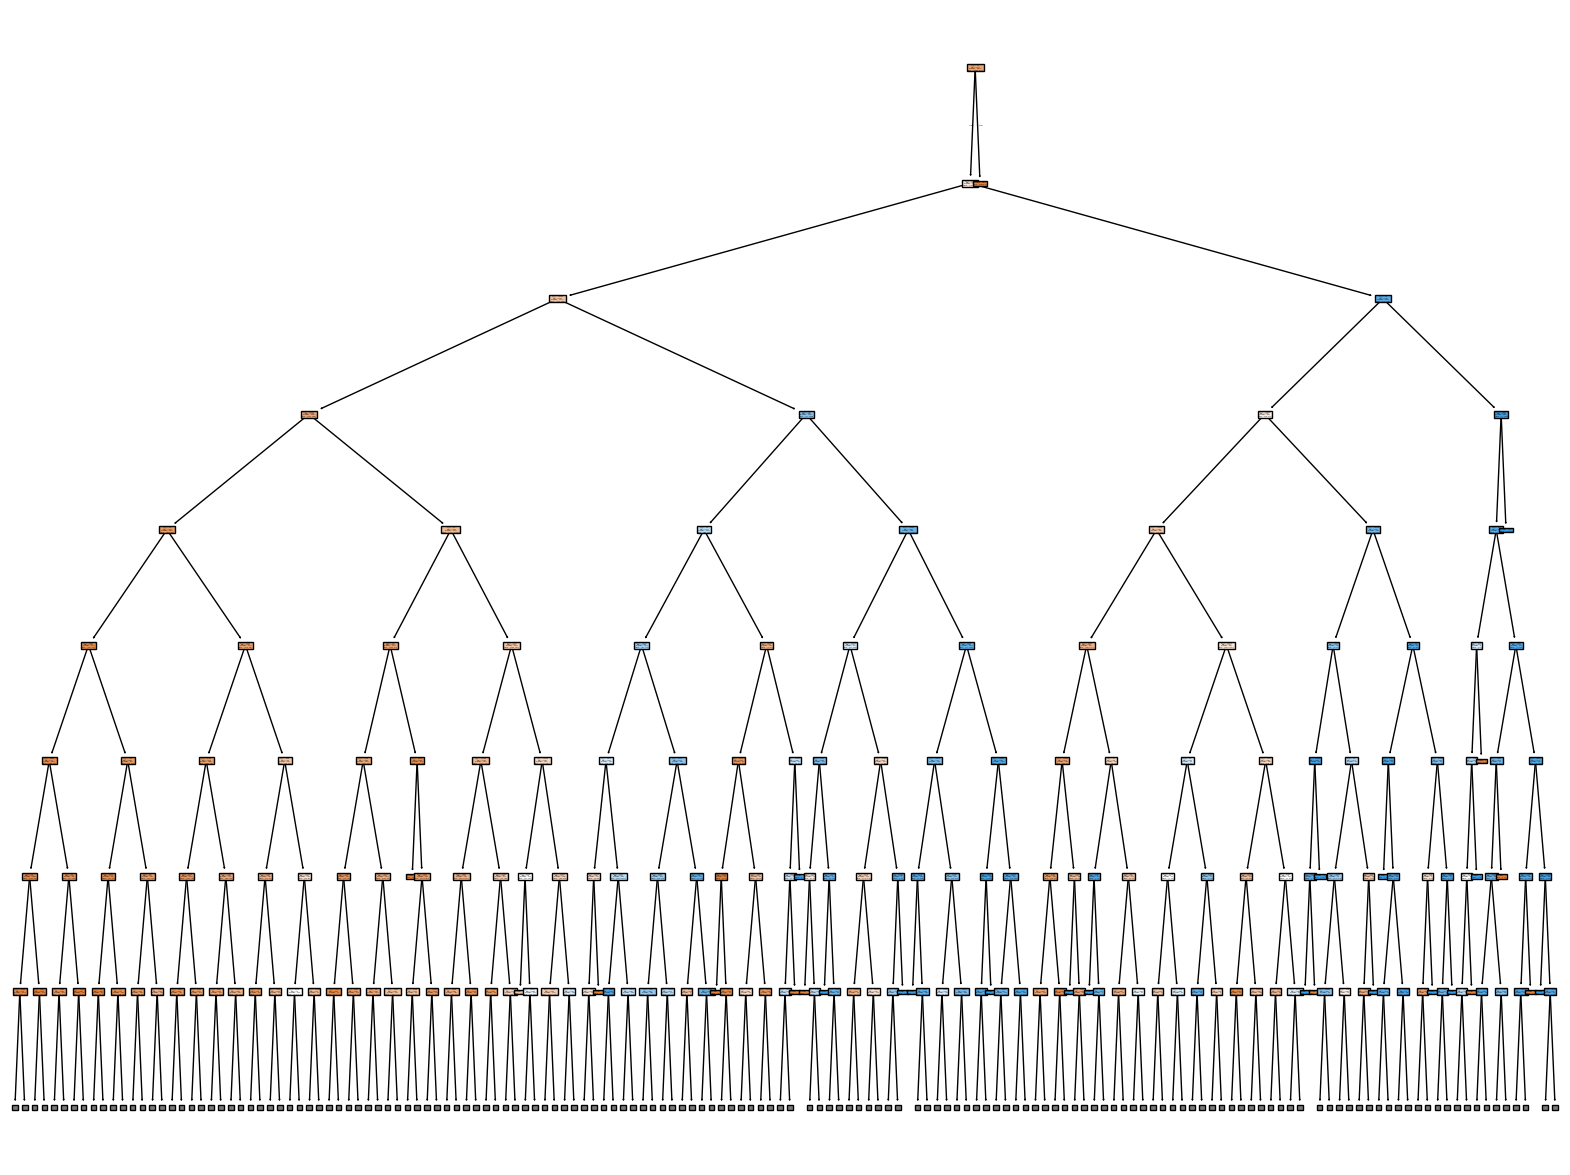

In [92]:
plt.figure(figsize=(20,15))  # Set the size of the plot

plot_tree(model,filled=True,max_depth =8)

plt.show()


<Axes: >

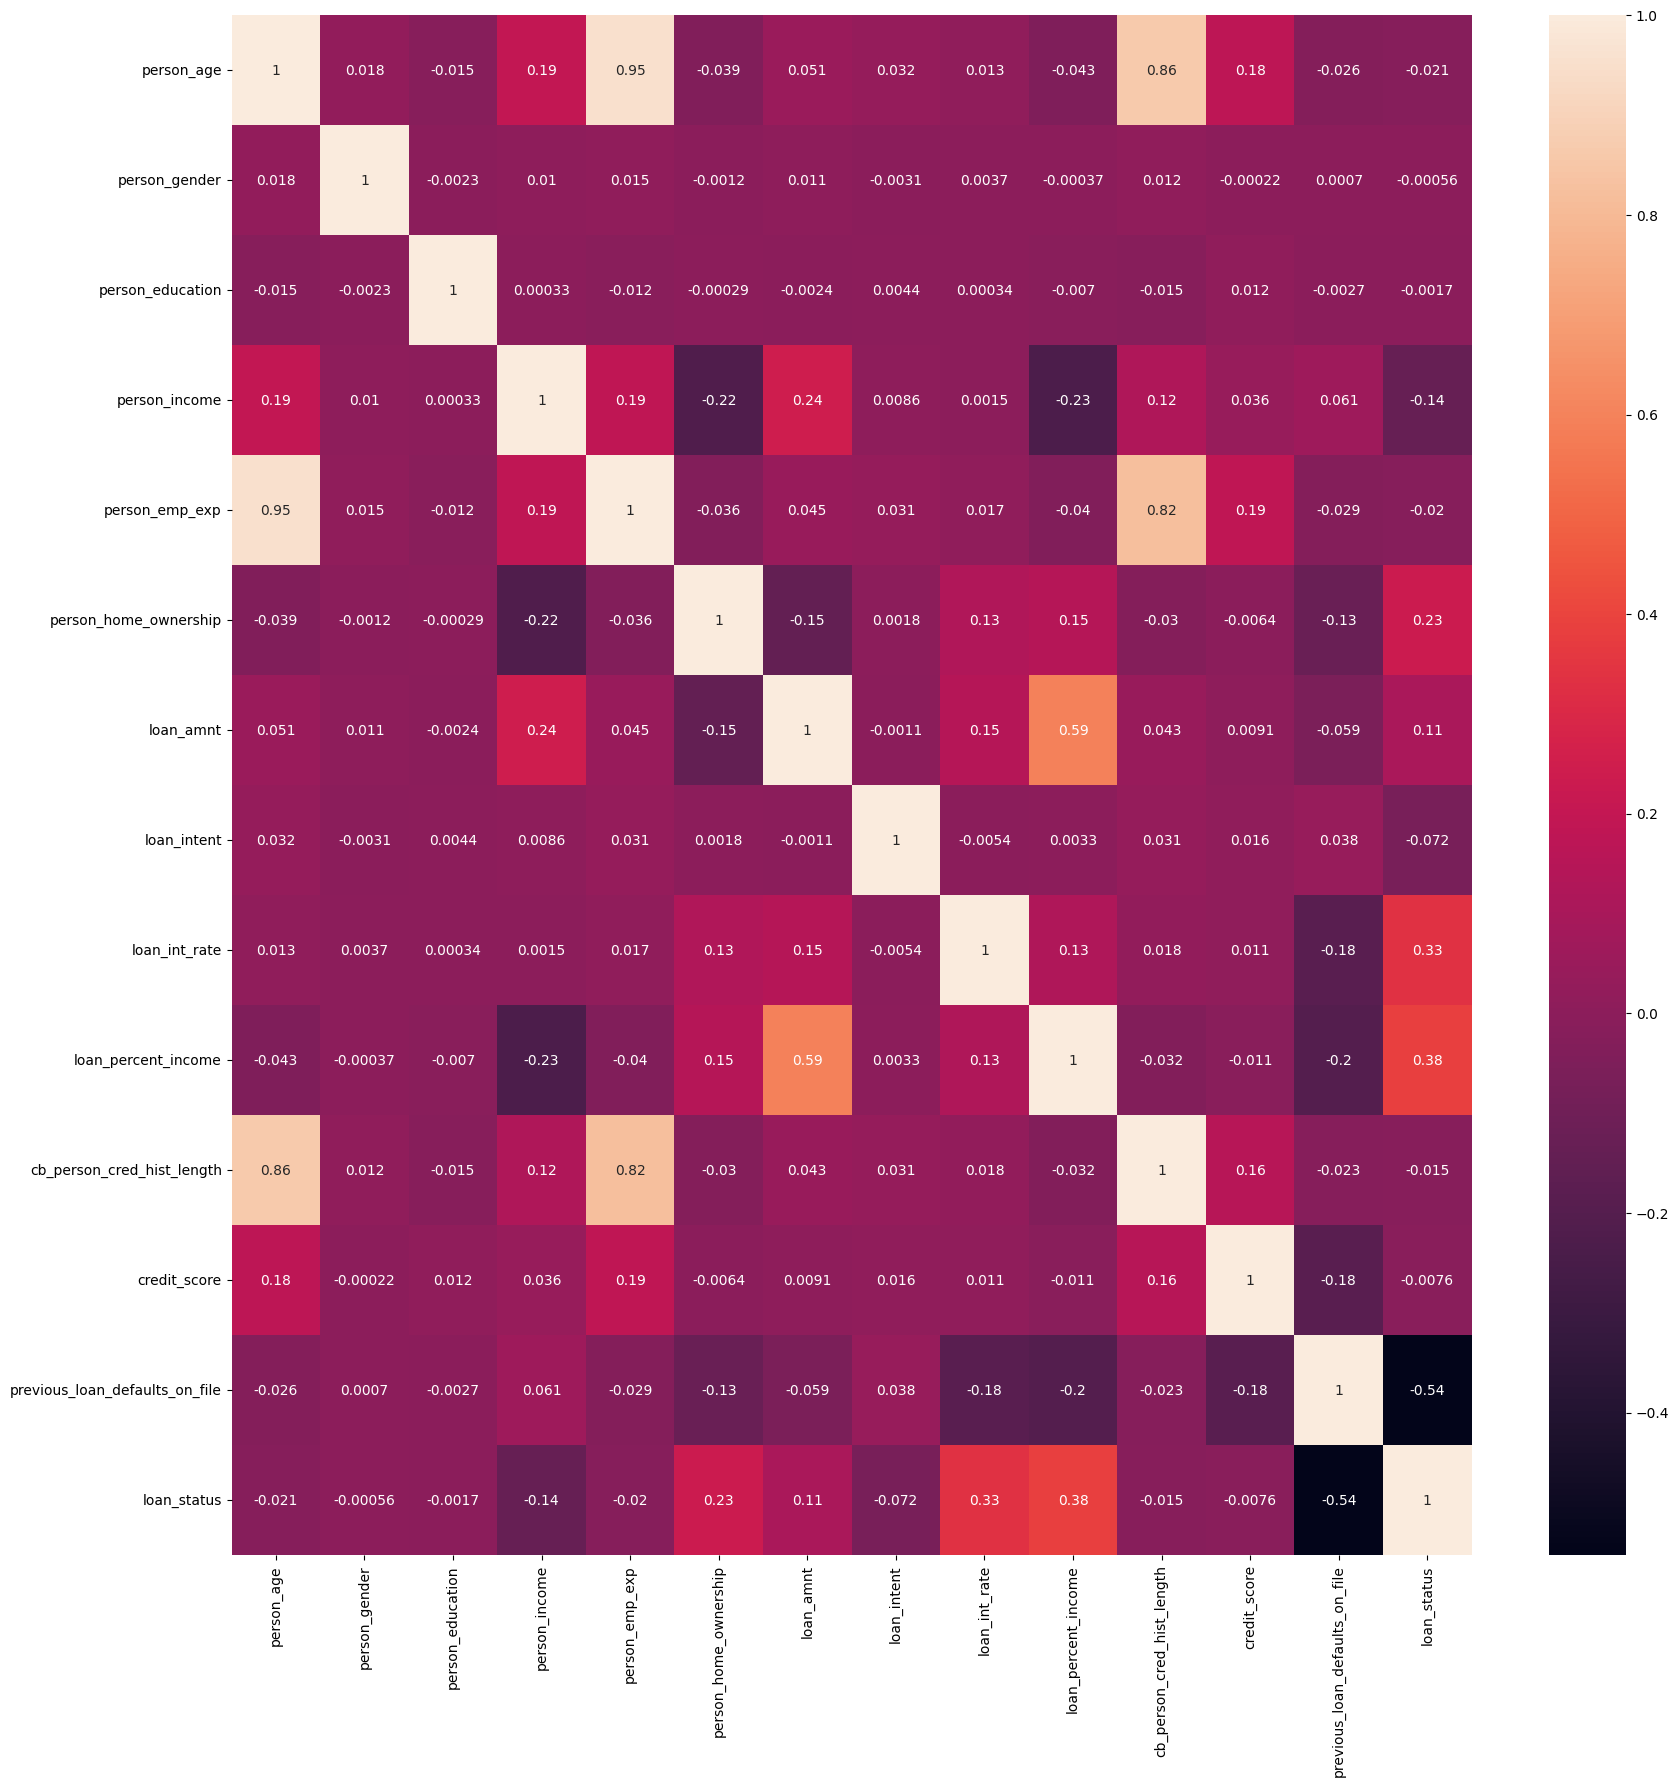

In [71]:
plt.figure(figsize=(20,20)) 
sns.heatmap(data = df.corr(),annot = True)

In [95]:
from sklearn.tree import export_graphviz

export_graphviz(model, out_file="tree.dot", 
                feature_names=["previous_loan_defaults_on_file","loan_percent_income","loan_int_rate","person_home_ownership"],
                class_names=['0','1'],
                filled=True)


### Regressor

In [32]:
data = pd.read_csv("./dataset/ford.csv")
data.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17965 entries, 0 to 17964
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17965 non-null  object 
 1   year          17965 non-null  int64  
 2   price         17965 non-null  int64  
 3   transmission  17965 non-null  object 
 4   mileage       17965 non-null  int64  
 5   fuelType      17965 non-null  object 
 6   tax           17965 non-null  int64  
 7   mpg           17965 non-null  float64
 8   engineSize    17965 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [28]:
data =df

In [37]:
data.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,12000,0,15944,4,150,57.7,1.0
1,6,2018,14000,1,9083,4,150,57.7,1.0
2,6,2017,13000,1,12456,4,150,57.7,1.0
3,5,2019,17500,1,10460,4,145,40.3,1.5
4,5,2019,16500,0,1482,4,145,48.7,1.0


In [30]:
le = LabelEncoder()

In [36]:
data["fuelType"] = le.fit_transform(data["fuelType"])

<Axes: >

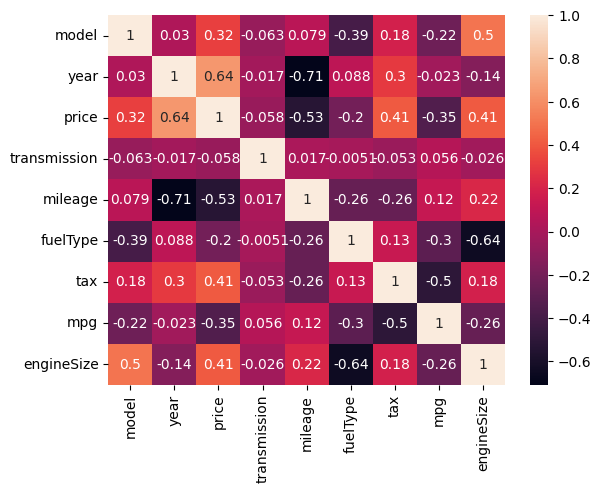

In [40]:
correlated = data.corr(numeric_only = True)
sns.heatmap(data = correlated,annot = True)

In [44]:
y_r = data["price"]

In [62]:
x_r = data[["mileage","transmission","year","engineSize","tax","model","mpg"]]

In [66]:
model = DecisionTreeRegressor()
x_train_r,x_test_r,y_train_r,y_test_r = train_test_split(x,y,test_size = 0.1,random_state = 42)
model.fit(x_train_r,y_train_r)

DecisionTreeRegressor()

In [67]:
y_pred_r = model.predict(x_train_r)
r2 = r2_score(y_train_r,y_pred_r)
r2*100

95.39625515901099

In [68]:
y_pred_r = model.predict(x_test_r)
r2 = r2_score(y_test_r,y_pred_r)
r2*100

11.49115632338803